# Feature Engineering for Insurance Claims
## Transforming Raw Data into Predictive Features

**Author:** Nandeesh H S  
**Project:** Insurance Risk Analytics & Claims Prediction

---

### Objectives
1. Create date-derived features (ages, durations)
2. Generate ratio and interaction features
3. Apply feature scaling and encoding
4. Perform feature selection
5. Prepare final datasets for modeling

In [1]:
# Import libraries
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path('..').resolve() / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from data_loader import DataLoader, create_target_variables
from feature_engineer import FeatureEngineer
from preprocessor import DataPreprocessor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load raw data
loader = DataLoader()
train_df, test_df = loader.load_data()

# Create targets
train_df = create_target_variables(train_df)

print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

INFO:data_loader:Loading datasets...


INFO:data_loader:Training data loaded: (37451, 28)


INFO:data_loader:Test data loaded: (15787, 23)


INFO:data_loader:Validating data quality...


INFO:data_loader:Data validation complete


INFO:data_loader:Target variables created successfully


INFO:data_loader:Claim rate: 11.08%


Training shape: (37451, 31)
Test shape: (15787, 23)


## 2. Feature Engineering

### 2.1 Date-Derived Features

In [3]:
# Apply feature engineering
engineer = FeatureEngineer()
train_fe = engineer.engineer_features(train_df, is_train=True)
test_fe = engineer.engineer_features(test_df, is_train=False)

print(f"\nAfter feature engineering:")
print(f"Training shape: {train_fe.shape}")
print(f"Test shape: {test_fe.shape}")

# Show new features
new_features = ['driver_age', 'driver_exp', 'vehicle_age', 'policy_duration',
                'power_to_weight', 'premium_to_value', 'loyalty',
                'driver_age_sq', 'vehicle_age_sq']

print("\nNew Features Created:")
for feat in new_features:
    if feat in train_fe.columns:
        print(f"  - {feat}")

Starting feature engineering for train data...
Feature engineering complete. New shape: (37451, 35)
Starting feature engineering for test data...


Feature engineering complete. New shape: (15787, 27)

After feature engineering:
Training shape: (37451, 35)
Test shape: (15787, 27)

New Features Created:
  - driver_age
  - driver_exp
  - vehicle_age
  - policy_duration
  - power_to_weight
  - premium_to_value
  - loyalty
  - driver_age_sq
  - vehicle_age_sq


### 2.2 Visualize New Features

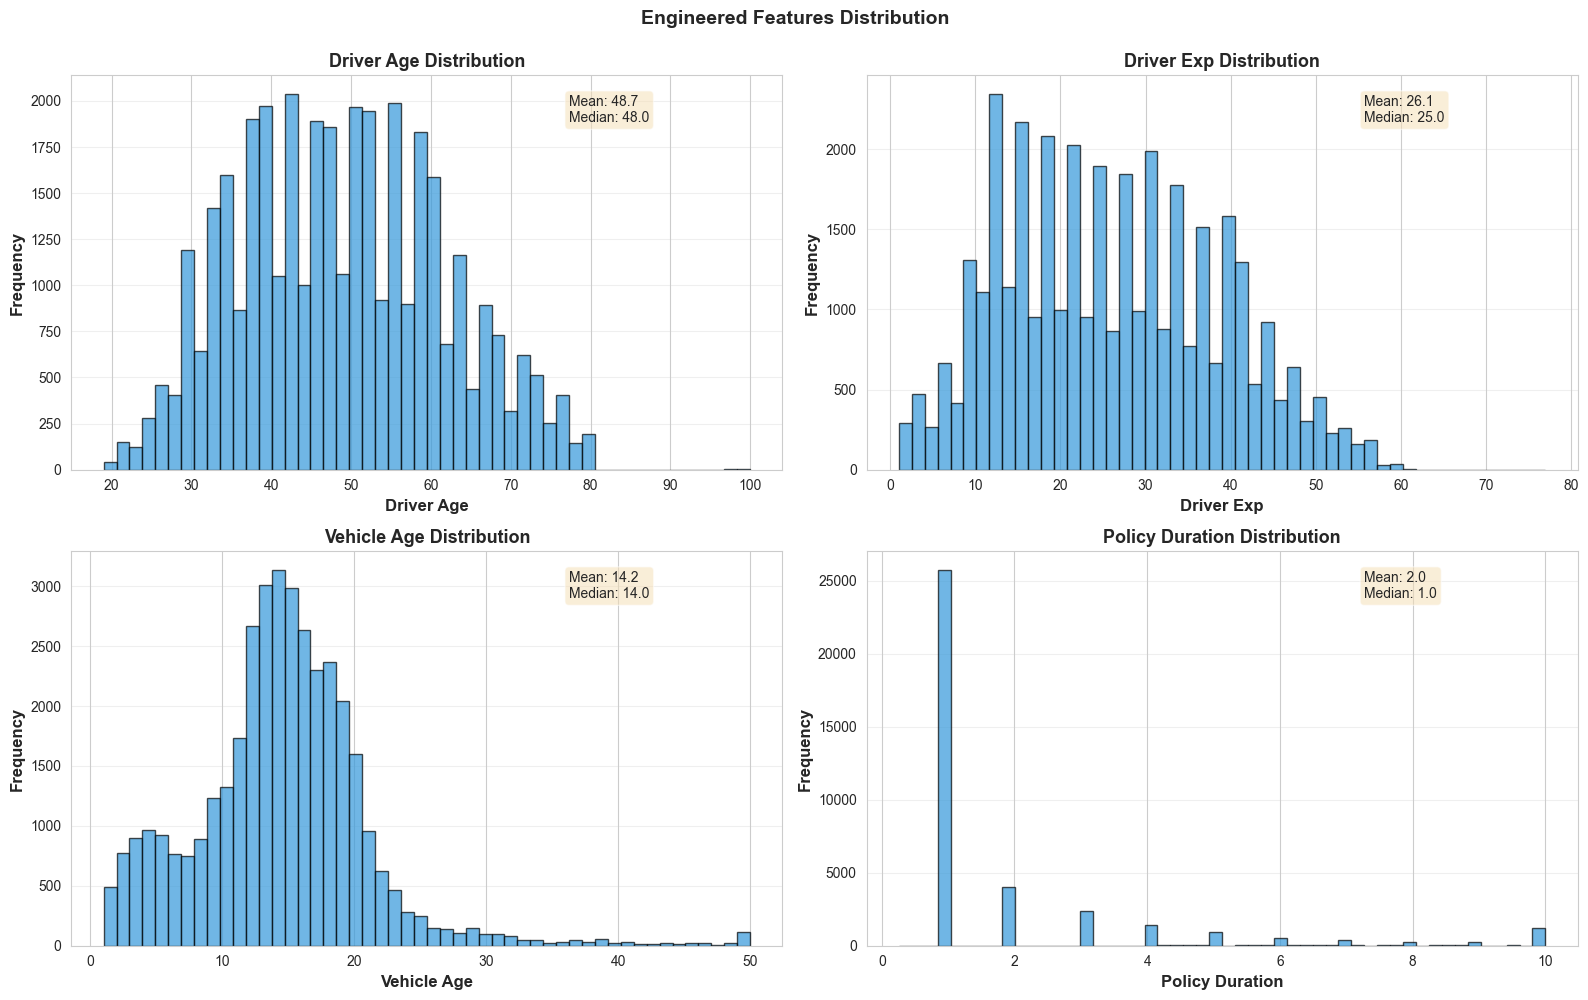

In [4]:
# Visualize engineered features
key_engineered = ['driver_age', 'driver_exp', 'vehicle_age', 'policy_duration']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_engineered):
    if col in train_fe.columns:
        axes[idx].hist(train_fe[col], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontsize=12, fontweight='bold')
        axes[idx].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=13, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add statistics
        stats_text = f"Mean: {train_fe[col].mean():.1f}\nMedian: {train_fe[col].median():.1f}"
        axes[idx].text(0.70, 0.95, stats_text,
                      transform=axes[idx].transAxes,
                      fontsize=10,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Engineered Features Distribution', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 2.3 Feature Relationship with Target

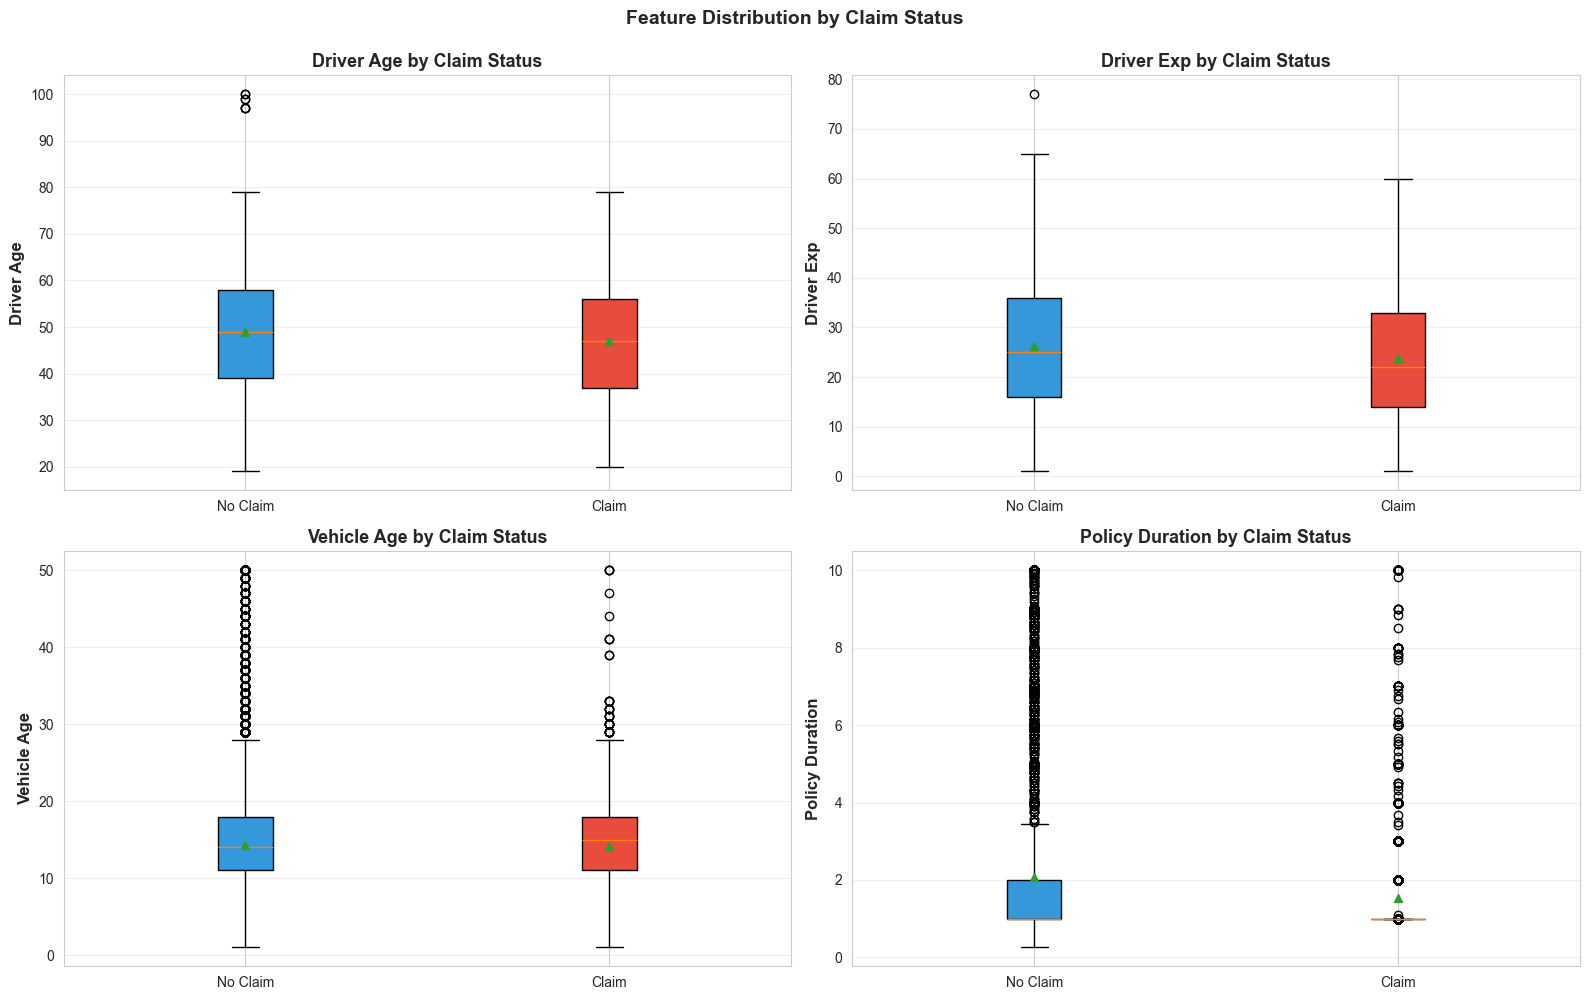


[INSIGHT] Different distributions between claim/no-claim groups indicate predictive power!


In [5]:
# Analyze relationship between engineered features and CS
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_engineered):
    if col in train_fe.columns and 'CS' in train_fe.columns:
        # Create boxplot for claim vs no claim
        data_to_plot = [train_fe[train_fe['CS']==0][col].dropna(),
                       train_fe[train_fe['CS']==1][col].dropna()]
        
        bp = axes[idx].boxplot(data_to_plot, labels=['No Claim', 'Claim'],
                              patch_artist=True, showmeans=True)
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('#3498db')
        bp['boxes'][1].set_facecolor('#e74c3c')
        
        axes[idx].set_ylabel(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        axes[idx].set_title(f'{col.replace("_", " ").title()} by Claim Status', 
                           fontsize=13, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distribution by Claim Status', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n[INSIGHT] Different distributions between claim/no-claim groups indicate predictive power!")

## 3. Data Preprocessing

### 3.1 Separate Features and Targets

In [6]:
# Initialize preprocessor
preprocessor = DataPreprocessor()

# Separate features and targets
X_train, X_test, targets = preprocessor.prepare_features_targets(train_fe, test_fe)

print(f"Features shape: {X_train.shape}")
print(f"\nTargets available:")
for target_name, target_values in targets.items():
    print(f"  {target_name}: {len(target_values)} samples")

Features shape: (37451, 27)

Targets available:
  CS: 37451 samples
  LC: 37451 samples
  HALC: 37451 samples


### 3.2 Categorical Encoding

In [7]:
# One-hot encode categorical variables
X_train_encoded, X_test_encoded = preprocessor.encode_categorical(X_train, X_test)

print(f"After encoding:")
print(f"  Training features: {X_train_encoded.shape[1]}")
print(f"  Test features: {X_test_encoded.shape[1]}")

Encoding 6 categorical variables...
Features after encoding: 29
After encoding:
  Training features: 29
  Test features: 29


### 3.3 Feature Scaling

In [8]:
# Scale features
X_train_scaled, X_test_scaled = preprocessor.scale_features(X_train_encoded, X_test_encoded)

print(f"Feature scaling complete!")
print(f"\nScaled feature statistics (training):")
print(f"  Mean: {X_train_scaled.mean().mean():.4f}")
print(f"  Std: {X_train_scaled.std().mean():.4f}")

Scaling features...
Feature scaling complete!

Scaled feature statistics (training):
  Mean: -0.0000
  Std: 1.0000


### 3.4 Feature Selection

In [9]:
# Feature selection using Random Forest importance
X_train_selected, X_test_selected, selected_features = preprocessor.select_features(
    X_train_scaled,
    X_test_scaled,
    targets['CS'],
    method='rf_importance'
)

print(f"\nSelected {len(selected_features)} features")
print(f"\nTop 10 selected features:")
for i, feat in enumerate(selected_features[:10], 1):
    print(f"  {i}. {feat}")

Selecting features using rf_importance...


Selected 15 features

Selected 15 features

Top 10 selected features:
  1. X.8
  2. X.9
  3. X.10
  4. X.12
  5. X.14
  6. X.23
  7. X.24
  8. X.25
  9. X.28
  10. driver_exp


### 3.5 Visualize Feature Importance

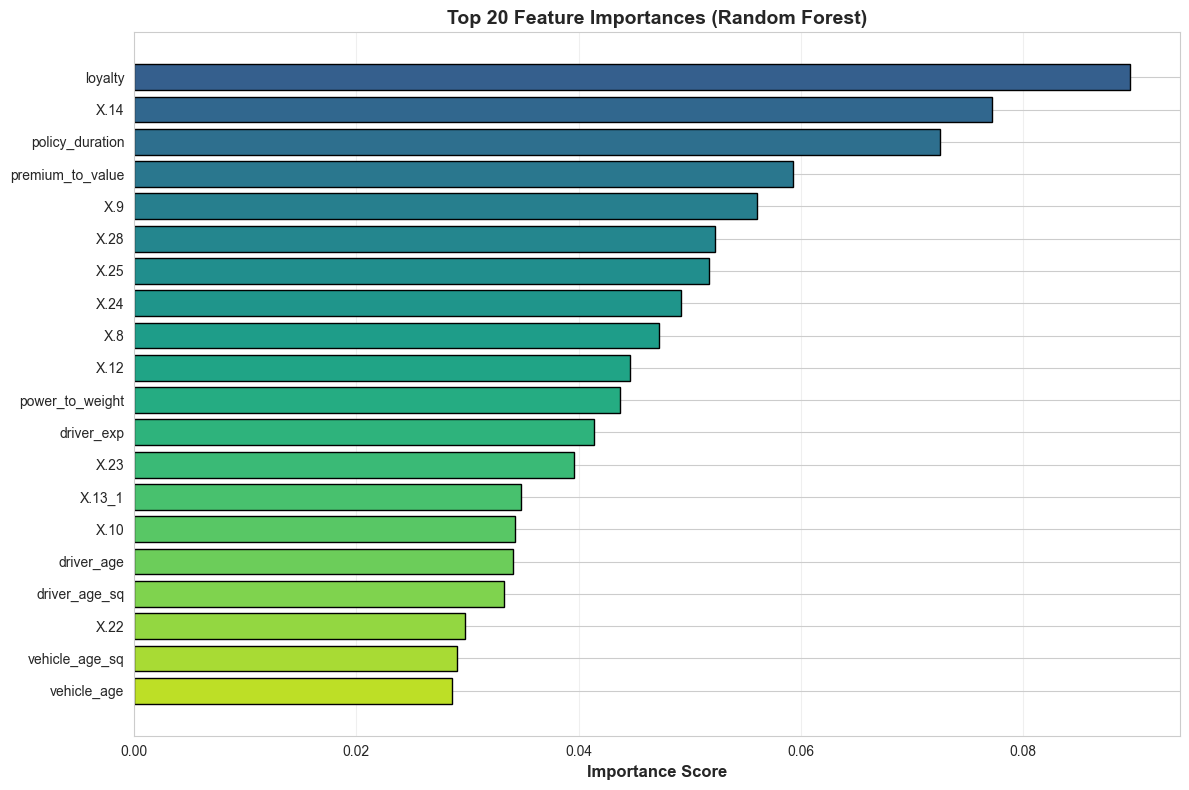

In [10]:
# Get feature importances from the selector
if preprocessor.feature_selector is not None:
    importances = preprocessor.feature_selector.estimator.feature_importances_
    feature_names = X_train_scaled.columns
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 20
    top_n = min(20, len(feature_names))
    top_importance = importance_df.head(top_n)
    
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_importance)))
    plt.barh(range(len(top_importance)), top_importance['importance'], color=colors, edgecolor='black')
    plt.yticks(range(len(top_importance)), top_importance['feature'], fontsize=10)
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Final Dataset Summary

In [11]:
print("="*80)
print("FINAL PREPROCESSED DATASETS")
print("="*80)
print(f"\nTraining Features:    {X_train_selected.shape}")
print(f"Test Features:        {X_test_selected.shape}")
print(f"\nTarget Variables:")
print(f"  CS (Claim Status):  {len(targets['CS']):,} samples")
print(f"  LC (Loss Cost):     {len(targets['LC']):,} samples")
print(f"  HALC:               {len(targets['HALC']):,} samples")
print(f"\nSelected Features:    {len(selected_features)}")
print("\n" + "="*80)
print("DATA READY FOR MODELING!")
print("="*80)

FINAL PREPROCESSED DATASETS

Training Features:    (37451, 15)
Test Features:        (15787, 15)

Target Variables:
  CS (Claim Status):  37,451 samples
  LC (Loss Cost):     37,451 samples
  HALC:               37,451 samples

Selected Features:    15

DATA READY FOR MODELING!


## 5. Key Takeaways

### Features Created:
1. **Date-derived**: driver_age, driver_exp, vehicle_age, policy_duration
2. **Ratios**: power_to_weight, premium_to_value, loyalty
3. **Polynomials**: driver_age_sq, vehicle_age_sq

### Preprocessing Applied:
1. One-hot encoding for categorical variables
2. StandardScaler for numerical features
3. Feature selection using Random Forest importance

### Next Steps:
- Train classification models (Notebook 03)
- Train regression models (Notebook 04)
- Compare modeling approaches (Notebook 05)